In [6]:
from models.drn.drn import drn_c_26
import torch
import torchvision.transforms as transforms
# from models.drn import data_transforms as transforms
from torchvision import datasets
from PIL import Image
model = drn_c_26(pretrained=True)
model.out_middle = True
model.out_map = True
n_middle_to_show = 6

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
labdir = './datasets/cls'
lab_loader = torch.utils.data.DataLoader(
datasets.ImageFolder(labdir, transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])),
batch_size=1, shuffle=False,
num_workers=0)

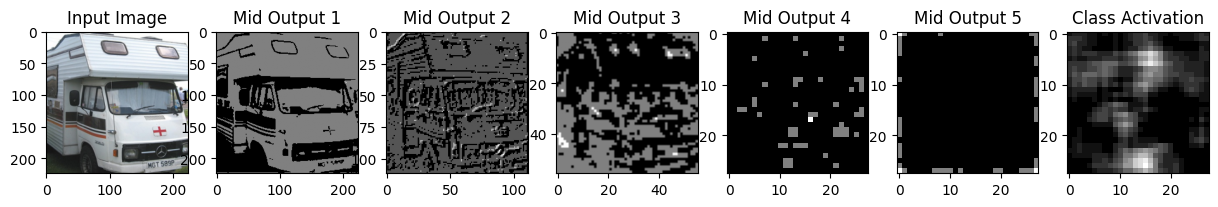

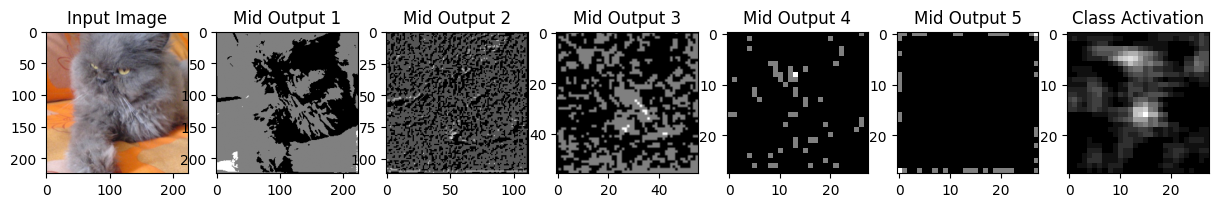

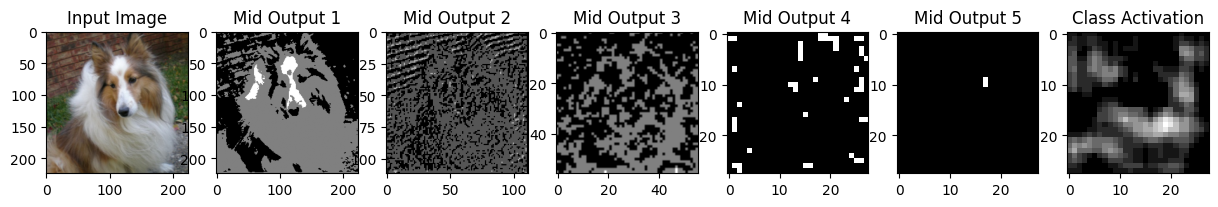

In [13]:
from tools.image_tools.image_tools import tensor2image, denormalize_tensor, get_max_avg_channel
import matplotlib.pyplot as plt
N = n_middle_to_show
for i, (input_tensor, label_tensor) in enumerate(lab_loader):
    class_activation, mid_outputs = model(input_tensor)
    # print(class_activation.shape)
    for i in range(input_tensor.size(0)):
        input_image = tensor2image(denormalize_tensor(input_tensor[i], IMAGENET_MEAN, IMAGENET_STD))
        mid_channel_max = [get_max_avg_channel(mid_outputs[j][i]) for j in range(len(mid_outputs))]
        output_images = [tensor2image(mid_channel_max[j], mode="gray") for j in range(len(mid_channel_max))]
        class_activation_image = tensor2image(get_max_avg_channel(class_activation[i]), mode="gray")
        plt.figure(figsize=(15,5))
        plt.subplot(1, N+1, 1)
        plt.imshow(input_image)
        plt.title("Input Image")
        for j in range(N):
            plt.subplot(1, N+1, j+2)
            plt.imshow(output_images[j], cmap='gray')
            plt.title(f"Mid Output {j+1}")
        plt.subplot(1, N+1, N+1)
        plt.imshow(class_activation_image, cmap='gray')
        plt.title("Class Activation")
        plt.show()
    # break

